In [1]:
"""
beyin tümörü sınıflandırma için transfer learning öğrenme uygulanması

ana model olarak densenet121 kullanılacak

transfer learning:önceden büyük veri setleri ile eğitilmiş convununtienal neural networlardir

modelin daha önceden eğitilmiş katmanı alınır ve kendi modelimize entegre edilir

sonrasında kendi sınıflandırma bloklarımızı ekliyoruz

"""

'\nzatürre sınıflandırma için transfer learning öğrenme uygulanması\n\nana model olarak densenet121 kullanılacak\n\ntransfer learning:önceden büyük veri setleri ile eğitilmiş convununtienal neural networlardir\n\nmodelin daha önceden eğitilmiş katmanı alınır ve kendi modelimize entegre edilir\n\nsonrasında kendi sınıflandırma bloklarımızı ekliyoruz\n\n'

In [12]:
#kütüphanelerin yüklenmesi
#import librarires
from tensorflow.keras.preprocessing.image import ImageDataGenerator #görüntü verisi yükleme ve aug
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense,Dropout,GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
import matplotlib.pyplot as plt
import os
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

In [ ]:
#dışarıdan büyük bir veri import ederken gereksiz bellek yer kaplar
# verinin hepsi sadece training asamasında kullanılacak
#bu flow from direct ile yapılacak ve generetorlar yazılacak

In [26]:
dir_path=r"C:\dl_proje\Görüntü_işleme_projeleri\Transfer_learning\brain_tumor_dataset"
target_size=(224,224)
waste_label={'no':0,'yes':1}

In [27]:
train_datagen=ImageDataGenerator(
    rescale=1/255.0, #normalizasyon 0-1 arasına sıkıstırma
    horizontal_flip=True,#yatayda cevirme
    vertical_flip=True,#dikeyde cevirme
    rotation_range=10 , #+-10 derece döndürme
    brightness_range=[0.8,1.2],
    validation_split=0.1,


    
)

test_datagen=ImageDataGenerator(
        rescale=1/255.0
        ,validation_split=0.3
    
)

In [30]:
train_generator=train_datagen.flow_from_directory(
    directory=dir_path,
    target_size=(target_size),
    class_mode='binary',
    subset='training',
    shuffle=True
    
)

test_generator=test_datagen.flow_from_directory(directory=dir_path,
                                        target_size=(target_size),
                                        class_mode='binary',
                                        subset='validation',
                                        batch_size=16
                                       )

Found 229 images belonging to 2 classes.
Found 75 images belonging to 2 classes.


In [32]:
class_names=list(train_generator.class_indices.keys())

In [34]:
image,label=next(train_generator)

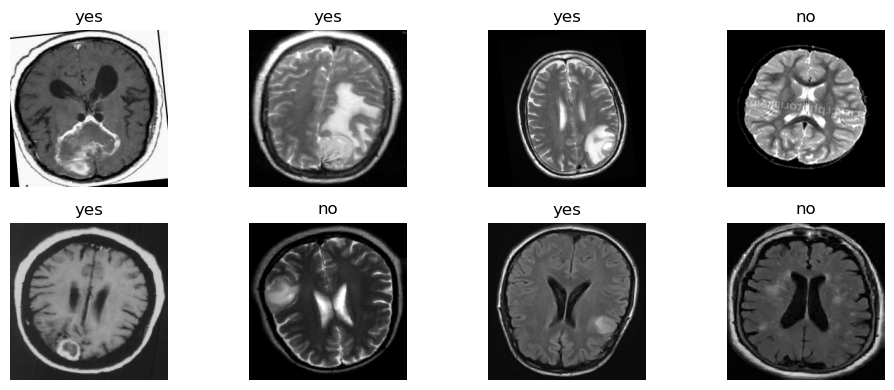

In [40]:
plt.figure(figsize=(10,4))

for i in range(8):
    ax=plt.subplot(2,4,i+1)
    ax.imshow(image[i])
    ax.set_title(class_names[int(label[i])])
    ax.axis("off")
plt.tight_layout()
plt.show()
           

In [48]:
#modelin tanımlanması

base_model=DenseNet121(
    weights="imagenet",#önceden egitilmiş modelin agırlıklarını alma
    include_top=False,#orijinal sınıflandırma katmanları dısarı atıldı biz kendi katmanımızı ekleyecegiz
    input_shape=(*target_size,3)
    
)

base_model.trainable=False #önceden eklenmiş modeli dondur base model train edilmeyecek
#sadece bizim son ekledigimiz katmanlar egitilecek

x=base_model.output
x=GlobalAveragePooling2D()(x)
x=Dense(128,activation="relu")(x)
x=Dropout(0.4)(x)
pred=Dense(1,activation="sigmoid")(x) #ikili sınıflandırma oldugu için 1 nöronlu cıktı katmanı

model=Model(inputs=base_model.input,outputs=pred)

In [50]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
    
)

callbacks=[
    EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss",factor=0.2,patience=2,min_lr=1e-6),
    ModelCheckpoint("bestmodel.h5",monitor="val_loss",save_best_only=True)
    
]

In [51]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_10             │ (None, 230, 230, 3)       │               0 │ input_layer_5[0][0]        │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d_10[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_11             │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_11[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,168,833 (27.35 MB)

 Trainable params: 131,329 (513.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [52]:
history=model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=15,
    callbacks=callbacks,
    verbose=1
    
)

C:\Users\Ömer faruk\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6236 - loss: 0.8059

8/8 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.6208 - loss: 0.7983 - val_accuracy: 0.6533 - val_loss: 0.6463 - learning_rate: 1.0000e-04
Epoch 2/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5685 - loss: 0.8159 

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.5723 - loss: 0.8093 - val_accuracy: 0.6667 - val_loss: 0.6172 - learning_rate: 1.0000e-04
Epoch 3/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6528 - loss: 0.6860 

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6516 - loss: 0.6829 - val_accuracy: 0.7333 - val_loss: 0.5623 - learning_rate: 1.0000e-04
Epoch 4/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6083 - loss: 0.6680

...

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7547 - loss: 0.4747 - val_accuracy: 0.8267 - val_loss: 0.4095 - learning_rate: 1.0000e-04
Epoch 12/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7968 - loss: 0.4539

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.7966 - loss: 0.4536 - val_accuracy: 0.8533 - val_loss: 0.3986 - learning_rate: 1.0000e-04
Epoch 13/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 990ms/step - accuracy: 0.7722 - loss: 0.4226

8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.7722 - loss: 0.4254 - val_accuracy: 0.8533 - val_loss: 0.3881 - learning_rate: 1.0000e-04
Epoch 14/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7906 - loss: 0.3980

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7901 - loss: 0.4008 - val_accuracy: 0.8533 - val_loss: 0.3800 - learning_rate: 1.0000e-04
Epoch 15/15
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8066 - loss: 0.4145

8/8 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8073 - loss: 0.4127 - val_accuracy: 0.9067 - val_loss: 0.3768 - learning_rate: 1.0000e-04


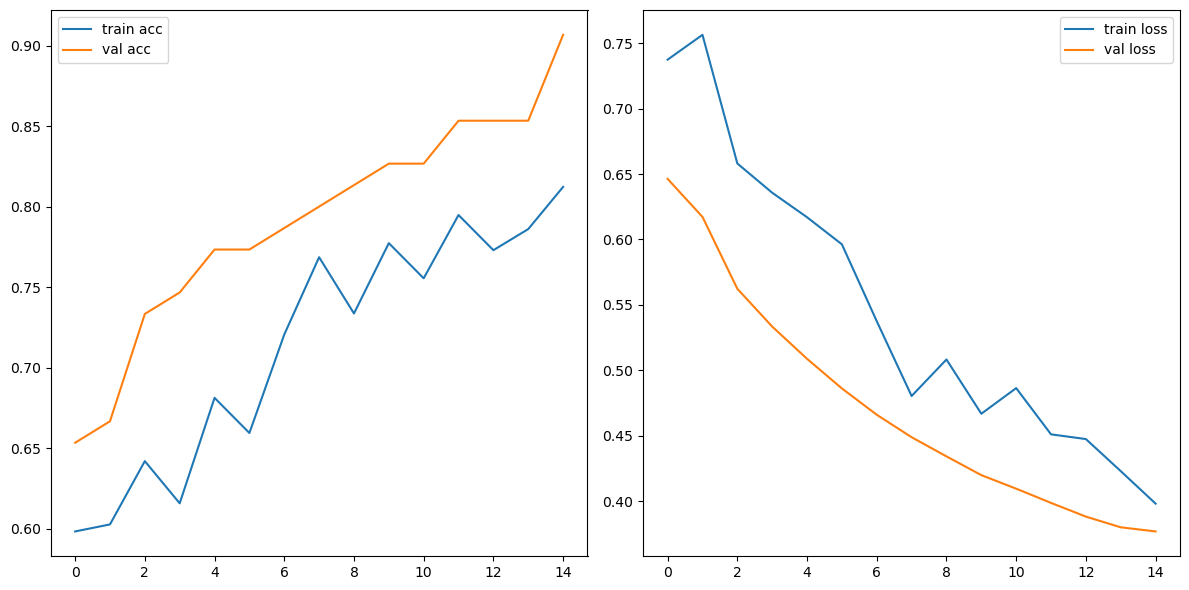

In [59]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"],label="train acc")
plt.plot(history.history["val_accuracy"],label="val acc")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"],label="train loss")
plt.plot(history.history["val_loss"],label="val loss")

plt.tight_layout()
plt.legend()
plt.show()